# RFM Customer Segmentation
## Dunnhumby — The Complete Journey

| | |
|---|---|
| **Dataset** | [Kaggle — Dunnhumby: The Complete Journey](https://www.kaggle.com/datasets/frtgnn/dunnhumby-the-complete-journey) |
| **Tools** | Python (pandas, numpy, matplotlib) → Power BI |
| **Output** | `rfm_segments.csv` → Power BI dashboard |
| **Business Problem** | Retailer treats all 2,500 households the same across campaigns. Who are the high-value customers, who is at risk of churning, and are we wasting promotion spend on customers who would have bought anyway? |

---
### Pipeline
```
0. Configuration
1. Imports
2. Data Loading
3. EDA & Data Quality
4. RFM Calculation
5. Customer Segmentation
6. Demographic Overlay
7. Campaign Response Analysis
8. Coupon Redemption Analysis
9. Visualisations
10. Export for Power BI
```

## 0. Configuration

In [1]:
# ── Update these paths before running ────────────────────────────────────────
DATA_DIR   = r'C:\Ongoing course\Projects\Dunnhumby RFM segmentation'
OUTPUT_DIR = r'C:\Ongoing course\Projects\Dunnhumby RFM segmentation\created'

# Reference day for recency = one day after the last transaction day (max DAY = 711)
REFERENCE_DAY = 712

## 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Data Loading

| File | Rows | Purpose |
|---|---|---|
| transaction_data.csv | ~2.6M | Spine of the project — all purchases |
| hh_demographic.csv | 801 | Demographics for 32% of households |
| campaign_table.csv | 7,208 | Which households received which campaigns |
| campaign_desc.csv | 30 | Campaign type and date windows |
| coupon_redempt.csv | 2,318 | Actual coupon redemption events |

In [3]:
df             = pd.read_csv(os.path.join(DATA_DIR, 'transaction_data.csv'))
demo           = pd.read_csv(os.path.join(DATA_DIR, 'hh_demographic.csv'))
campaign_tbl   = pd.read_csv(os.path.join(DATA_DIR, 'campaign_table.csv'))
campaign_dsc   = pd.read_csv(os.path.join(DATA_DIR, 'campaign_desc.csv'))
coupon_redempt = pd.read_csv(os.path.join(DATA_DIR, 'coupon_redempt.csv'))

print(f"transaction_data : {df.shape}")
print(f"hh_demographic   : {demo.shape}")
print(f"campaign_table   : {campaign_tbl.shape}")
print(f"campaign_desc    : {campaign_dsc.shape}")
print(f"coupon_redempt   : {coupon_redempt.shape}")

transaction_data : (2595732, 12)
hh_demographic   : (801, 8)
campaign_table   : (7208, 3)
campaign_desc    : (30, 4)
coupon_redempt   : (2318, 4)


## 3. EDA & Data Quality Checks

### Key findings from EDA
- **No negative SALES_VALUE** — returns not recorded as negatives
- **18,850 zero-value rows** — items where discounts wiped price to \$0 (fully comped)
- **942 fully-zero baskets** — entire trips where customer paid nothing (0.34% of baskets)
- **RETAIL_DISC positive max (+3.99)** — rounding/correction artefacts, treated as zero
- **hh_demographic covers only 801/2,500 households** — 32% coverage, stated as limitation

### Data cleaning decisions
| Metric | Rule | Reason |
|---|---|---|
| Monetary | `SALES_VALUE > 0` only | \$0 items add nothing to spend |
| Frequency | ALL distinct baskets | Measures engagement, not spend — M handles spend |
| Recency | Reference day = 712 | One day after max DAY of 711 |

In [4]:
# ── Transaction profile ──────────────────────────────────────────────────────
print(f"Unique households  : {df['household_key'].nunique()}")
print(f"DAY range          : {df['DAY'].min()} - {df['DAY'].max()}")
print(f"SALES_VALUE min    : {df['SALES_VALUE'].min()}")
print()
print("SALES_VALUE distribution:")
print(df['SALES_VALUE'].describe())

Unique households  : 2500
DAY range          : 1 - 711
SALES_VALUE min    : 0.0

SALES_VALUE distribution:
count    2.595732e+06
mean     3.104120e+00
std      4.182274e+00
min      0.000000e+00
25%      1.290000e+00
50%      2.000000e+00
75%      3.490000e+00
max      8.400000e+02
Name: SALES_VALUE, dtype: float64


In [5]:
# ── Zero-value row analysis ──────────────────────────────────────────────────
zero_rows     = df[df['SALES_VALUE'] == 0]
basket_totals = df.groupby('BASKET_ID')['SALES_VALUE'].sum()
fully_zero    = basket_totals[basket_totals == 0]

print(f"Zero-value rows           : {len(zero_rows):,}")
print(f"Baskets with >=1 zero item: {zero_rows['BASKET_ID'].nunique():,}")
print(f"Fully zero baskets        : {len(fully_zero):,} ({len(fully_zero)/len(basket_totals)*100:.2f}% of all baskets)")

Zero-value rows           : 18,850
Baskets with >=1 zero item: 16,305
Fully zero baskets        : 942 (0.34% of all baskets)


In [6]:
# ── Demographic coverage ─────────────────────────────────────────────────────
coverage = demo['household_key'].nunique() / df['household_key'].nunique()
print(f"Demographic coverage: {demo['household_key'].nunique()} / {df['household_key'].nunique()} households ({coverage:.1%})")
print()
print("Discount column ranges (negatives = discounts applied):")
print(df[['RETAIL_DISC','COUPON_DISC','COUPON_MATCH_DISC']].describe().round(3))

Demographic coverage: 801 / 2500 households (32.0%)

Discount column ranges (negatives = discounts applied):
       RETAIL_DISC  COUPON_DISC  COUPON_MATCH_DISC
count  2595732.000  2595732.000        2595732.000
mean        -0.539       -0.016             -0.003
std          1.249        0.217              0.040
min       -180.000      -55.930             -7.700
25%         -0.690        0.000              0.000
50%         -0.010        0.000              0.000
75%          0.000        0.000              0.000
max          3.990        0.000              0.000


## 4. RFM Calculation

| Metric | Formula | Scoring |
|---|---|---|
| **Recency (R)** | `712 − MAX(DAY)` per household | Lower days = more recent = Score 5. Labels **inverted**: `[5,4,3,2,1]` |
| **Frequency (F)** | `COUNT(DISTINCT BASKET_ID)` | Higher visits = Score 5. Labels: `[1,2,3,4,5]` |
| **Monetary (M)** | `SUM(SALES_VALUE > 0)` | Higher spend = Score 5. Labels: `[1,2,3,4,5]` |

**Why `pd.qcut` (quintile binning) and not `pd.cut` (equal width)?**  
All three metrics are right-skewed (std > mean, extreme outliers). Equal-width bins would push 90%+ of households into Score 1, making the metric useless. Quintile binning ensures ~500 households per bucket regardless of distribution shape.

**Why `rank(method='first')` on Frequency?**  
Many households share identical visit counts. `pd.qcut` fails with duplicate bin edges. `rank()` converts tied values into unique ranks before binning.

In [7]:
# ── 4.1 Raw metrics per household ────────────────────────────────────────────
recency   = REFERENCE_DAY - df.groupby('household_key')['DAY'].max()
frequency = df.groupby('household_key')['BASKET_ID'].nunique()
monetary  = df[df['SALES_VALUE'] > 0].groupby('household_key')['SALES_VALUE'].sum()

rfm = pd.concat([recency, frequency, monetary], axis=1)
rfm.columns = ['recency_days', 'frequency', 'monetary']
rfm = rfm.reset_index()

print(f"RFM table shape : {rfm.shape}")
print(f"Null values     : {rfm.isnull().sum().sum()}")
print()
print("RFM summary:")
rfm[['recency_days', 'frequency', 'monetary']].describe().round(2)

RFM table shape : (2500, 4)
Null values     : 0

RFM summary:


,recency_days,frequency,monetary
count,2500.00,2500.00,2500.00
mean,26.57,110.59,3222.99
std,62.79,115.67,3349.03
min,1.00,1.00,8.17
25%,2.00,39.00,970.74
50%,7.00,79.00,2157.75
75%,21.00,142.25,4413.32
max,658.00,1300.00,38319.79


In [8]:
# ── 4.2 Quintile scoring ─────────────────────────────────────────────────────
rfm['R'] = pd.qcut(rfm['recency_days'].rank(method='first'), q=5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'),    q=5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['monetary'],                          q=5, labels=[1,2,3,4,5])

# convert Categorical to int before arithmetic and comparisons
rfm['R'] = rfm['R'].astype(int)
rfm['F'] = rfm['F'].astype(int)
rfm['M'] = rfm['M'].astype(int)

rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

print(f"RFM Score range : {rfm['RFM_Score'].min()} - {rfm['RFM_Score'].max()}")
print(f"RFM Score mean  : {rfm['RFM_Score'].mean():.2f}")
print()
print("Score bucket sizes (each should be ~500):")
rfm[['R','F','M']].apply(pd.Series.value_counts).fillna(0).astype(int)

RFM Score range : 3 - 15
RFM Score mean  : 9.00

Score bucket sizes (each should be ~500):


,R,F,M
1,500,500,500
2,500,500,500
3,500,500,500
4,500,500,500
5,500,500,500


## 5. Customer Segmentation

Rule-based segmentation using `np.select()`. Conditions checked in order — **first match wins**. Most specific rules placed first.

| Segment | Rule | Meaning |
|---|---|---|
| Champions | R≥4 AND F≥4 AND M≥4 | Recent, frequent, high spenders |
| Loyal | F≥4 AND R≥3 | Consistent shoppers |
| Potential Loyalists | R≥4 AND F∈[2,3] | Recent but not yet frequent |
| At Risk | R∈[2,3] AND F≥2 AND M≥2 | Were good, drifting away |
| New Customers | R=5 AND F=1 | First-time, very recent |
| Lost | R=1 | Haven't shopped in very long time |
| One-time Buyers | R∈[2,3,4] AND F=1 | Visited once, didn't return |
| Low Value | R∈[2,3] AND F≥2 AND M=1 | Regular visitors, near-zero spend |


In [9]:
r = rfm['R']
f = rfm['F']
m = rfm['M']

conditions = [
    (r >= 4) & (f >= 4) & (m >= 4),              # Champions
    (f >= 4) & (r >= 3),                           # Loyal
    (r >= 4) & ((f == 2) | (f == 3)),              # Potential Loyalists
    ((r == 2) | (r == 3)) & (f >= 2) & (m >= 2),  # At Risk
    (r == 5) & (f == 1),                           # New Customers
    (r == 1),                                       # Lost
    ((r == 2) | (r == 3) | (r == 4)) & (f == 1),  # One-time Buyers
    ((r == 2) | (r == 3)) & (f >= 2) & (m == 1),  # Low Value
]

choices = [
    'Champions', 'Loyal', 'Potential Loyalists', 'At Risk',
    'New Customers', 'Lost', 'One-time Buyers', 'Low Value',
]

rfm['segment'] = np.select(conditions, choices, default='Others')

print("Segment counts:")
print(rfm['segment'].value_counts())
print(f"\nUncategorised (Others): {(rfm['segment'] == 'Others').sum()}")

Segment counts:
segment
At Risk                565
Champions              509
Lost                   500
Loyal                  330
Potential Loyalists    306
One-time Buyers        198
Low Value               62
New Customers           30
Name: count, dtype: int64

Uncategorised (Others): 0


## 6. Demographic Overlay

> **Limitation:** Only 801 of 2,500 households have demographic data (32% coverage).  
> All findings in this section are **indicative only** — not universal.

**Join type: LEFT JOIN** — keeps all 2,500 households from rfm, fills `NaN` where no demographic match exists.

In [10]:
rfm_demo = pd.merge(rfm, demo, on='household_key', how='left')

print(f"Post-merge shape        : {rfm_demo.shape}")
print(f"Households without demo : {rfm_demo['INCOME_DESC'].isnull().sum()}")

Post-merge shape        : (2500, 16)
Households without demo : 1699


In [11]:
# filter to households with known demographics
rfm_known = rfm_demo[rfm_demo['INCOME_DESC'].notnull()].copy()

# correct income band order — alphabetical sort is wrong for these strings
income_order = [
    'Under 15K', '15-24K', '25-34K', '35-49K', '50-74K',
    '75-99K', '100-124K', '125-149K', '150-174K',
    '175-199K', '200-249K', '250K+'
]
size_order = ['1', '2', '3', '4', '5+']

# normalize='index' → segment mix within each income band (row %)
# answers: 'Of all 50-74K households, what % are Champions?'
income_ct = pd.crosstab(
    rfm_known['INCOME_DESC'], rfm_known['segment'], normalize='index'
).reindex(income_order)

size_ct = pd.crosstab(
    rfm_known['HOUSEHOLD_SIZE_DESC'], rfm_known['segment'], normalize='index'
).reindex(size_order)

print("Segment mix by income band (row %):")
income_ct.round(2)

Segment mix by income band (row %):


segment,At Risk,Champions,Lost,Low Value,Loyal,One-time Buyers,Potential Loyalists
INCOME_DESC,,,,,,,
Under 15K,0.21,0.49,0.05,0.00,0.20,0.00,0.05
15-24K,0.20,0.35,0.09,0.00,0.27,0.00,0.08
25-34K,0.16,0.39,0.08,0.00,0.25,0.00,0.13
35-49K,0.16,0.44,0.06,0.01,0.20,0.01,0.12
50-74K,0.19,0.43,0.03,0.01,0.24,0.01,0.09
75-99K,0.20,0.39,0.06,0.00,0.19,0.00,0.17
100-124K,0.24,0.44,0.03,0.00,0.24,0.00,0.06
125-149K,0.21,0.45,0.08,0.00,0.18,0.03,0.05
150-174K,0.30,0.37,0.07,0.00,0.23,0.00,0.03


## 7. Campaign Response Analysis

**Response definition:** A household is flagged as a responder if they made at least one transaction within their campaign's `START_DAY` to `END_DAY` window.

> ⚠ **Important caveat:** High response rates reflect **baseline shopping frequency**, not campaign effectiveness.  
> Average campaign window = ~47 days. Median household visits every 9 days regardless of campaign exposure.  
> Most households would transact in any 47-day window whether or not they received a campaign.

**Key finding:** Champions are over-targeted (499/509 = 98%) while At Risk (172 unreached) and Lost (333 unreached) are under-reached.

In [12]:
# ── Step 1: attach campaign windows to each household ────────────────────────
camp = pd.merge(campaign_tbl, campaign_dsc[['CAMPAIGN', 'START_DAY', 'END_DAY']], on='CAMPAIGN', how='left')

# ── Step 2: attach all transactions for targeted households ───────────────────
camp_txn = pd.merge(
    camp,
    df[['household_key', 'BASKET_ID', 'DAY']],
    on='household_key', how='left'
)

# ── Step 3: keep only transactions within campaign window ─────────────────────
responded = camp_txn[
    (camp_txn['DAY'] >= camp_txn['START_DAY']) &
    (camp_txn['DAY'] <= camp_txn['END_DAY'])
]

print(f"Rows within campaign windows : {responded.shape[0]:,}")
print(f"Unique responding households : {responded['household_key'].nunique():,}")

Rows within campaign windows : 994,137
Unique responding households : 1,552


In [13]:
camp.columns.tolist()

['DESCRIPTION', 'household_key', 'CAMPAIGN', 'START_DAY', 'END_DAY']

In [14]:
# ── Step 4: flag responders at household-campaign level ──────────────────────
responders = (
    responded.groupby(['household_key', 'CAMPAIGN'])['BASKET_ID']
    .count().reset_index()
)
responders.columns = ['household_key', 'CAMPAIGN', 'txn_count']
responders['responded'] = 1

camp_response = pd.merge(
    camp[['household_key', 'CAMPAIGN', 'DESCRIPTION']].drop_duplicates(),
    responders[['household_key', 'CAMPAIGN', 'responded']],
    on=['household_key', 'CAMPAIGN'], how='left'
)
camp_response['responded'] = camp_response['responded'].fillna(0).astype(int)

print(f"Total household-campaign pairs : {camp_response.shape[0]}")
print(camp_response['responded'].value_counts())

Total household-campaign pairs : 7208
responded
1    7056
0     152
Name: count, dtype: int64


In [15]:
# ── Step 5: response rate by segment ─────────────────────────────────────────
camp_seg = pd.merge(
    camp_response,
    rfm_demo[['household_key', 'segment']],
    on='household_key', how='left'
)

overall_avg    = camp_response['responded'].mean()
response_rate  = camp_seg.groupby('segment')['responded'].mean().round(3).sort_values(ascending=False)
targeted_count = camp_seg.groupby('segment')['household_key'].nunique()

print(f"Overall response rate : {overall_avg:.1%}")
print()
print("Response rate by segment:")
print(response_rate)
print()
print("Households targeted by segment:")
print(targeted_count)

Overall response rate : 97.9%

Response rate by segment:
segment
New Customers          1.000
Loyal                  0.999
Champions              0.996
Potential Loyalists    0.972
At Risk                0.968
Low Value              0.923
Lost                   0.863
One-time Buyers        0.812
Name: responded, dtype: float64

Households targeted by segment:
segment
At Risk                393
Champions              499
Lost                   167
Low Value                9
Loyal                  310
New Customers            2
One-time Buyers         20
Potential Loyalists    184
Name: household_key, dtype: int64


## 8. Coupon Redemption Analysis

Unlike campaign response (contaminated by baseline shopping frequency), coupon redemption requires an **active customer choice** — presenting a coupon. This gives cleaner behavioural signal.

> ⚠ **Counterintuitive finding:** Champions have the highest redemption rate (42.8%), not the lowest.  
> **Why?** Redemption correlates with visit frequency, not income. Champions visit most often — more trips = more coupon touchpoints.  
> Lost customers rarely see coupons because they are not in-store.

> 🔑 **Key finding:** Champions = 20.4% of households → 60.1% of all coupon value.  
> Coupons reward existing loyalty rather than building new loyalty.

In [16]:
coupon_counts = (
    coupon_redempt.groupby('household_key')['COUPON_UPC']
    .count().reset_index()
)
coupon_counts.columns = ['household_key', 'redemption_count']

coupon_seg = pd.merge(
    rfm_demo[['household_key', 'segment']],
    coupon_counts, on='household_key', how='left'
)
coupon_seg['redemption_count'] = coupon_seg['redemption_count'].fillna(0).astype(int)
coupon_seg['redeemed']         = (coupon_seg['redemption_count'] > 0).astype(int)

redemption_rate = coupon_seg.groupby('segment')['redeemed'].mean().round(3).sort_values(ascending=False)
avg_redemptions = coupon_seg.groupby('segment')['redemption_count'].mean().round(2).sort_values(ascending=False)

print("Redemption rate by segment:")
print(redemption_rate)
print()
print("Avg redemptions per household:")
print(avg_redemptions)

Redemption rate by segment:
segment
Champions              0.428
Loyal                  0.279
Potential Loyalists    0.111
At Risk                0.110
Lost                   0.054
One-time Buyers        0.005
Low Value              0.000
New Customers          0.000
Name: redeemed, dtype: float64

Avg redemptions per household:
segment
Champions              2.74
Loyal                  1.33
At Risk                0.43
Potential Loyalists    0.42
Lost                   0.23
One-time Buyers        0.01
Low Value              0.00
New Customers          0.00
Name: redemption_count, dtype: float64


In [17]:
# ── Concentration analysis ────────────────────────────────────────────────────
total_redemptions = coupon_seg['redemption_count'].sum()
champ_redemptions = coupon_seg[coupon_seg['segment'] == 'Champions']['redemption_count'].sum()
total_households  = rfm.shape[0]
champ_households  = rfm[rfm['segment'] == 'Champions'].shape[0]

print(f"Champions share of all redemptions : {champ_redemptions/total_redemptions:.1%}")
print(f"Champions share of households      : {champ_households/total_households:.1%}")

Champions share of all redemptions : 60.1%
Champions share of households      : 20.4%


## 9. Visualisations

In [18]:
# ── Shared variables ─────────────────────────────────────────────────────────
segment_counts     = rfm['segment'].value_counts()
score_counts       = rfm['RFM_Score'].value_counts().sort_index()
segment_avg        = rfm.groupby('segment')[['R', 'F', 'M']].mean().round(2)
segments           = response_rate.index.tolist()
rates              = response_rate.values.tolist()
targeted           = [targeted_count[s] for s in segments]
overall_redemption = coupon_seg['redeemed'].mean()

### 9.1 — 9.4 RFM Overview Charts

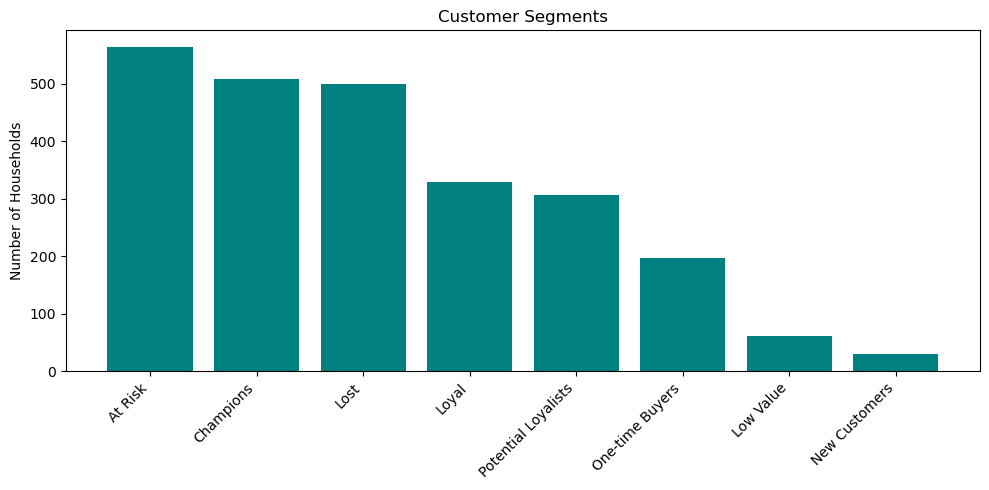

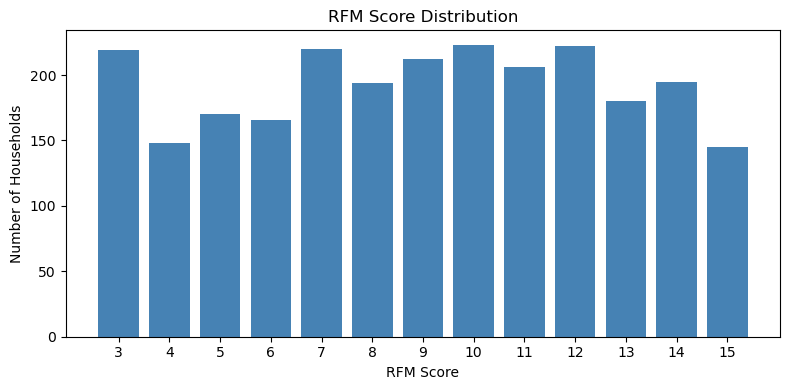

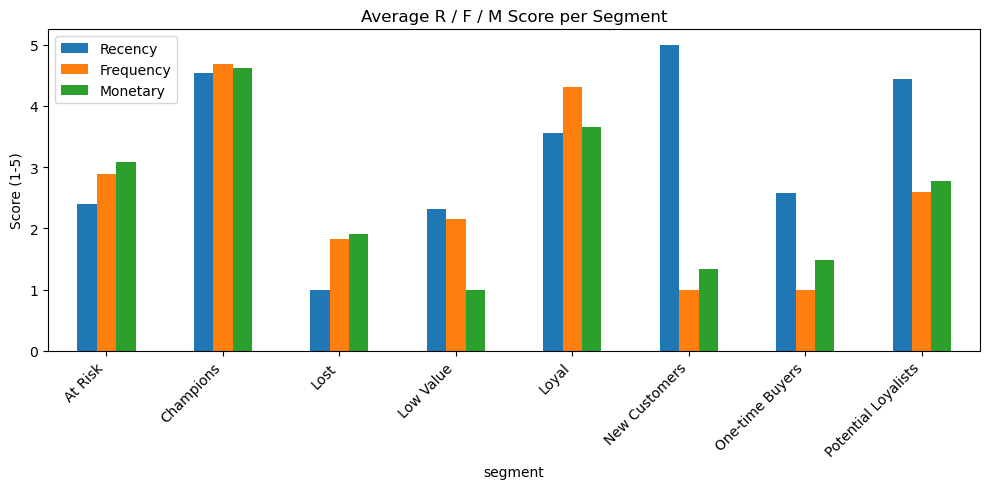

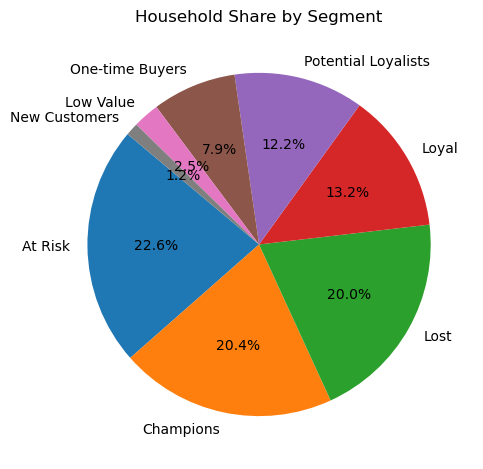

In [19]:
# 9.1 Segment distribution
plt.figure(figsize=(10, 5))
plt.bar(segment_counts.index, segment_counts.values, color='teal')
plt.title('Customer Segments')
plt.ylabel('Number of Households')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 9.2 RFM Score distribution
plt.figure(figsize=(8, 4))
plt.bar(score_counts.index, score_counts.values, color='steelblue')
plt.title('RFM Score Distribution')
plt.xlabel('RFM Score')
plt.ylabel('Number of Households')
plt.xticks(score_counts.index)
plt.tight_layout()
plt.show()

# 9.3 Avg R/F/M per segment
segment_avg.plot(kind='bar', figsize=(10, 5))
plt.title('Average R / F / M Score per Segment')
plt.ylabel('Score (1-5)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Recency', 'Frequency', 'Monetary'])
plt.tight_layout()
plt.show()

# 9.4 Household share donut
plt.figure(figsize=(5, 5))
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Household Share by Segment')
plt.tight_layout()
plt.show()

### 9.5 — 9.6 Demographic Charts

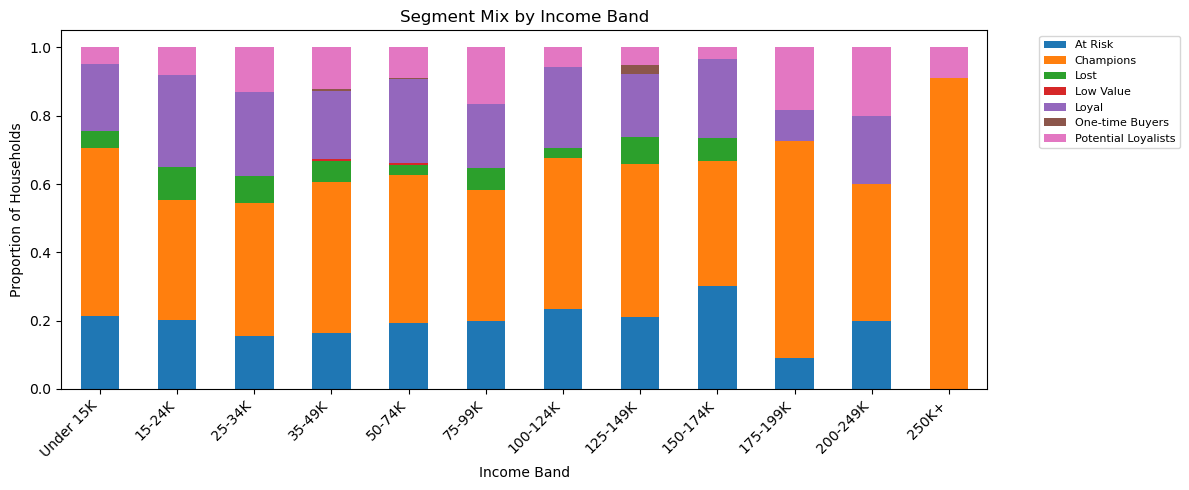

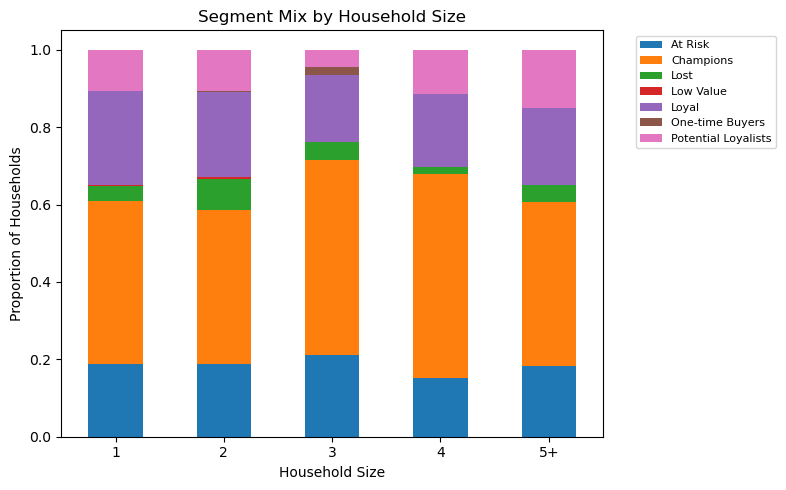

In [20]:
# 9.5 Segment mix by income band
income_ct.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Segment Mix by Income Band')
plt.ylabel('Proportion of Households')
plt.xlabel('Income Band')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# 9.6 Segment mix by household size
size_ct.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Segment Mix by Household Size')
plt.ylabel('Proportion of Households')
plt.xlabel('Household Size')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 9.7 — 9.9 Campaign Charts

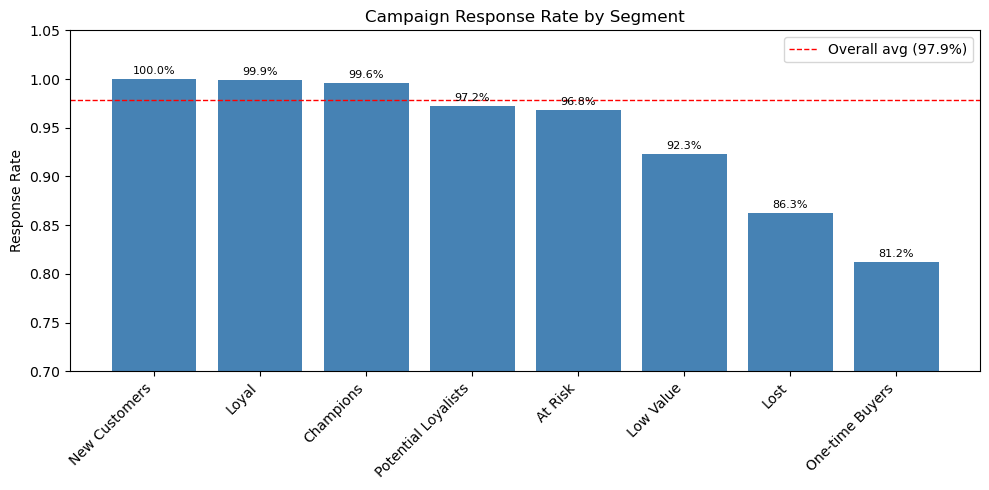

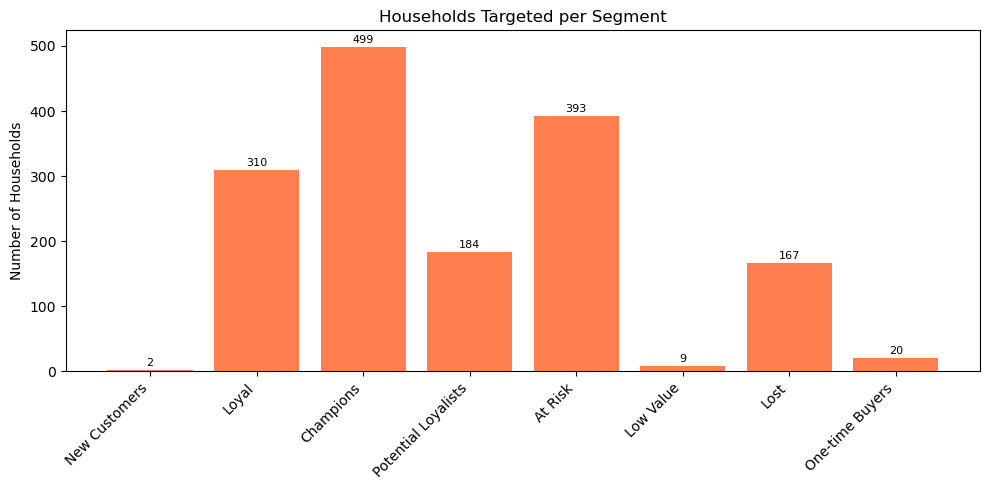

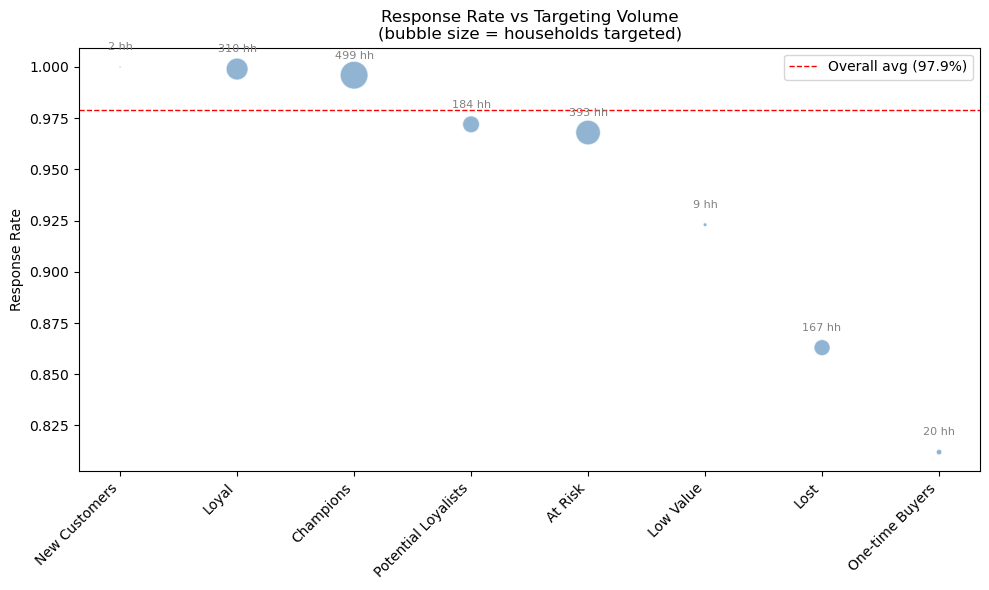

In [21]:
# 9.7 Campaign response rate by segment
plt.figure(figsize=(10, 5))
bars = plt.bar(segments, rates, color='steelblue')
plt.axhline(y=overall_avg, color='red', linestyle='--', linewidth=1,
            label=f'Overall avg ({overall_avg:.1%})')
plt.title('Campaign Response Rate by Segment')
plt.ylabel('Response Rate')
plt.ylim(0.7, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend()
for bar, val in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.1%}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# 9.8 Targeting volume by segment
plt.figure(figsize=(10, 5))
bars2 = plt.bar(segments, targeted, color='coral')
plt.title('Households Targeted per Segment')
plt.ylabel('Number of Households')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars2, targeted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# 9.9 Response rate vs targeting volume (bubble chart)
plt.figure(figsize=(10, 6))
x = range(len(segments))
plt.scatter(x, rates, s=[t * 0.8 for t in targeted],
            color='steelblue', alpha=0.6, edgecolors='white', linewidth=0.8)
plt.axhline(y=overall_avg, color='red', linestyle='--', linewidth=1,
            label=f'Overall avg ({overall_avg:.1%})')
plt.xticks(x, segments, rotation=45, ha='right')
plt.ylabel('Response Rate')
plt.title('Response Rate vs Targeting Volume\n(bubble size = households targeted)')
for i, (seg, rate, tgt) in enumerate(zip(segments, rates, targeted)):
    plt.annotate(f'{tgt} hh', (i, rate), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=8, color='gray')
plt.legend()
plt.tight_layout()
plt.show()

### 9.10 — 9.12 Coupon Charts

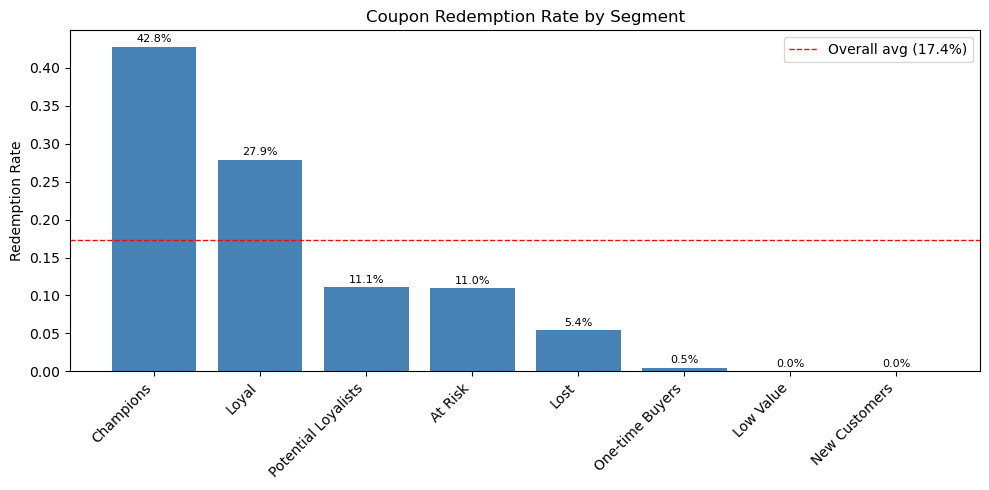

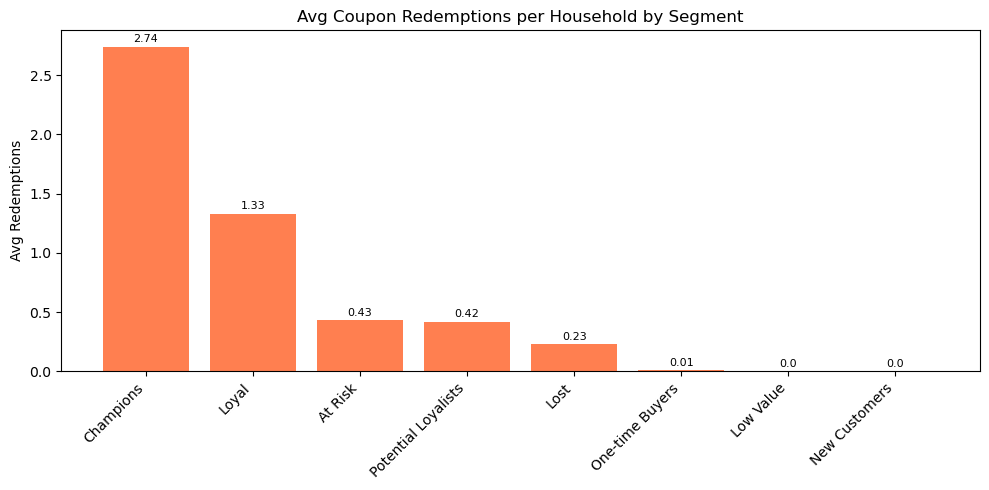

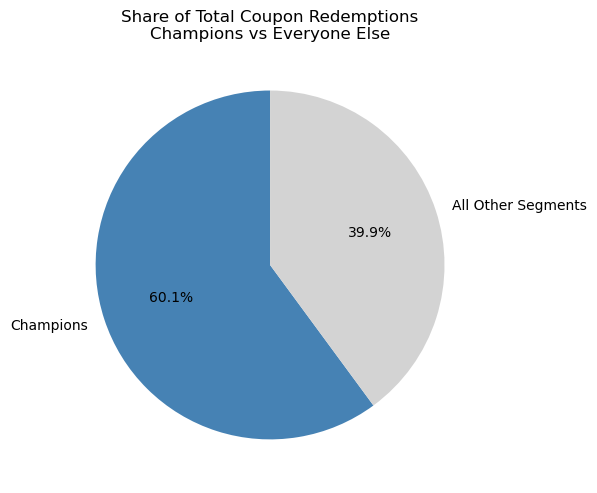

In [22]:
# 9.10 Coupon redemption rate by segment
plt.figure(figsize=(10, 5))
bars3 = plt.bar(redemption_rate.index, redemption_rate.values, color='steelblue')
plt.axhline(y=overall_redemption, color='red', linestyle='--', linewidth=1,
            label=f'Overall avg ({overall_redemption:.1%})')
plt.title('Coupon Redemption Rate by Segment')
plt.ylabel('Redemption Rate')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars3, redemption_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.1%}', ha='center', va='bottom', fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

# 9.11 Avg redemptions per household
plt.figure(figsize=(10, 5))
bars4 = plt.bar(avg_redemptions.index, avg_redemptions.values, color='coral')
plt.title('Avg Coupon Redemptions per Household by Segment')
plt.ylabel('Avg Redemptions')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars4, avg_redemptions.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# 9.12 Redemption concentration — Champions vs everyone else
other_redemptions = total_redemptions - champ_redemptions
plt.figure(figsize=(6, 6))
plt.pie([champ_redemptions, other_redemptions],
        labels=['Champions', 'All Other Segments'],
        autopct='%1.1f%%', colors=['steelblue', 'lightgray'], startangle=90)
plt.title('Share of Total Coupon Redemptions\nChampions vs Everyone Else')
plt.tight_layout()
plt.show()

## 10. Export for Power BI

Only one file needs to be exported from Python — `rfm_segments.csv`.  
Everything else (KPIs, monthly revenue, campaign/coupon rates) will be built directly in Power BI using DAX.

In [23]:
rfm_segments = rfm_demo[[
    'household_key', 'recency_days', 'frequency', 'monetary',
    'R', 'F', 'M', 'RFM_Score', 'segment',
    'INCOME_DESC', 'HOUSEHOLD_SIZE_DESC', 'AGE_DESC',
    'MARITAL_STATUS_CODE', 'HH_COMP_DESC', 'KID_CATEGORY_DESC'
]]

output_path = os.path.join(OUTPUT_DIR, 'rfm_segments.csv')
rfm_segments.to_csv(output_path, index=False)

print(f"Exported : {output_path}")
print(f"Shape    : {rfm_segments.shape}  (expected: 2500 x 15)")
print()
print("Final segment counts:")
print(rfm_segments['segment'].value_counts())
print()
print("Python pipeline complete. Load rfm_segments.csv into Power BI.")

Exported : C:\Ongoing course\Projects\Dunnhumby RFM segmentation\created\rfm_segments.csv
Shape    : (2500, 15)  (expected: 2500 x 15)

Final segment counts:
segment
At Risk                565
Champions              509
Lost                   500
Loyal                  330
Potential Loyalists    306
One-time Buyers        198
Low Value               62
New Customers           30
Name: count, dtype: int64

Python pipeline complete. Load rfm_segments.csv into Power BI.
